#### **Machine Learning and Data Science Research Project - Research (Vectorized)**

**Project:** Reinforcement Learning for Optimal Execution - GPU Accelerated Version

**Author:** Robert de Witt (CID: 02541719)

**Note:** This is a vectorized version optimized for GPU acceleration and faster training.


In [1]:
import pandas as pd
import time
from notebook_logging_setup import quick_setup
from gymnasium.utils.env_checker import check_env
from stable_baselines3 import PPO
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
import torch
import torch.nn as nn
import numpy as np
import random
import gc
import psutil

# my libraries
from mkt_data_yfinance import MarketDataLoader as mdl
import render_plots as rp
import model_parking as mp
from optimal_execution_env_vectorized import VectorizedMultiOrderExecutionEnv
from vectorized_env_wrapper import create_vectorized_env, compare_models_consistently
from order_generator import OrderGenerator
import baseline_strategies as bs
import gpu_utils

quick_setup(debug=False)
fixed_seed = 42
np.random.seed(fixed_seed)
random.seed(fixed_seed)  # Also seed the random module

device = gpu_utils.get_torch_device()
gpu_utils.set_random_seed(fixed_seed)

print(f"Using device: {device}")
print(f"GPU Memory Available: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB" if device == 'cuda' else "")
print(f"MPS Available: {torch.backends.mps.is_available()}" if device == 'mps' else "")

2025-07-19 09:52:41.280667: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-19 09:52:41.290665: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752915161.302624 2025817 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752915161.305632 2025817 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752915161.314282 2025817 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Logging configured at INFO level
2025-07-19 09:52:44 - root - INFO - Using CUDA GPU: NVIDIA GeForce RTX 4090
2025-07-19 09:52:44 - root - INFO - CUDA Device Count: 1
2025-07-19 09:52:44 - root - INFO - Current CUDA Device: 0
Using device: cuda
GPU Memory Available: 24.0 GB



In [2]:
# Vectorized environment configuration
max_trading_rate = 0.8
max_order_size_in_adv_pct = 0.1
num_vec_envs_gpu = 64 
num_vec_envs_cpu = 256
batch_size = 64

# Stock selection - optimized for vectorized processing
tickers = ['AAPL','MSFT','GOOGL','AMZN','TSLA','NVDA','JPM','V','JNJ','DIS', 'NKE', 'PYPL', 'ADBE', 'NFLX', 'INTC', 'CMCSA', 'PEP', 'MRK', 'VZ', 'T']

print(f"Vectorized configuration:")
print(f"  - Num vectorized environments: GPU: {num_vec_envs_gpu} and CPU: {num_vec_envs_cpu}")
print(f"  - Device: {device}")
print(f"  - Batch size: {batch_size}")
print(f"  - Max trading rate: {max_trading_rate}")
print(f"  - Max order size (ADV %): {max_order_size_in_adv_pct}")

# Load market data with progress tracking
print("\nLoading market data...")
start_time = time.time()
md = mdl()
stock_df_list = md.load_data(tickers, horizon='7d')
stock_df_list = md.pre_process_data(stock_df_list)
load_time = time.time() - start_time
print(f"Data loaded in {load_time:.2f} seconds")

# Check available dates
sample_df = stock_df_list[list(stock_df_list.keys())[0]]
dates = pd.to_datetime(sample_df.index.date).unique()
print(f"Available dates: {len(dates)} days from {dates[0]} to {dates[-1]}")


Vectorized configuration:
  - Num vectorized environments: GPU: 64 and CPU: 256
  - Device: cuda
  - Batch size: 64
  - Max trading rate: 0.8
  - Max order size (ADV %): 0.1

Loading market data...
YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Data loaded in 17.33 seconds
Available dates: 7 days from 2025-07-10 00:00:00 to 2025-07-18 00:00:00


**Order Generation**

The order generation process creates a set of trading orders with the following characteristics:
1.  For each order, a random stock is selected from the available universe, and its Average Daily Volume (ADV) is calculated as the mean of daily trading volumes.
2. The order size is determined by sampling a random percentage of ADV between min_adv_pct and max_adv_pct, scaled by the time horizon (as a fraction of the trading day). This ensures that larger orders are spread over longer time periods and that the orders can complete within the time horizon given 
3. The execution window is defined by randomly selecting a start time and a time horizon (in minutes) between min_time_horizon and max_time_horizon, with the end time being start_time + time_horizon.
4. Each order is assigned a random side (buy/sell) and its quantity is rounded to the nearest integer, with safeguards to prevent zero-sized orders. The resulting orders are then used to train or evaluate the execution strategy in the reinforcement learning environment.
5. For simplicity's sake, we will not apply order constraints such as limit prices or volume limits, we will assume lit market trading only and we will not worry about auctions.

In [3]:
# Create train/test split using date filtering with larger batches for vectorized processing
print("Generating training orders...")
start_time = time.time()

# Training set: first 5 days (exclude last 2 days) - larger batch for vectorized processing
train_orders_df = OrderGenerator(
    stock_df_list=stock_df_list, 
    market_data=md, 
    debug=False, 
    max_adv_pct=max_order_size_in_adv_pct, 
    num_orders=2000,  # Increased for vectorized processing
    sd_delta=0,  # Start from first day
    ed_delta=2,   # Exclude last 2 days
    seed=fixed_seed
).get_orders()

train_time = time.time() - start_time
print(f"Training orders generated in {train_time:.2f} seconds")

print("Generating test orders...")
start_time = time.time()

# Test set: last 2 days (exclude first 5 days) - larger batch for vectorized processing
test_orders_df = OrderGenerator(
    stock_df_list=stock_df_list, 
    market_data=md, 
    debug=False, 
    max_adv_pct=max_order_size_in_adv_pct, 
    num_orders=500,  # Increased for vectorized processing
    sd_delta=5,  # Skip first 5 days
    ed_delta=0,   # Include up to last day
    seed=fixed_seed
).get_orders()

test_time = time.time() - start_time
print(f"Test orders generated in {test_time:.2f} seconds")

# Verify the date split
print(f"\nTrain set: {len(train_orders_df)} orders")
print(f"Train dates: {train_orders_df['date'].min()} to {train_orders_df['date'].max()}")
print(f"Orders per day (train):\n{train_orders_df['date'].value_counts().sort_index()}")

print(f"\nTest set: {len(test_orders_df)} orders")
print(f"Test dates: {test_orders_df['date'].min()} to {test_orders_df['date'].max()}")
print(f"Orders per day (test):\n{test_orders_df['date'].value_counts().sort_index()}")

# Verify no overlap
train_dates = set(train_orders_df['date'].unique())
test_dates = set(test_orders_df['date'].unique())
print(f"\nDate overlap: {train_dates.intersection(test_dates)}")
print(f"No overlap verified: {len(train_dates.intersection(test_dates)) == 0}")


Generating training orders...
Training orders generated in 1.57 seconds
Generating test orders...
Test orders generated in 0.39 seconds

Train set: 2000 orders
Train dates: 2025-07-10 00:00:00 to 2025-07-16 00:00:00
Orders per day (train):
date
2025-07-10    400
2025-07-11    400
2025-07-14    400
2025-07-15    400
2025-07-16    400
Name: count, dtype: int64

Test set: 500 orders
Test dates: 2025-07-17 00:00:00 to 2025-07-18 00:00:00
Orders per day (test):
date
2025-07-17    250
2025-07-18    250
Name: count, dtype: int64

Date overlap: set()
No overlap verified: True


3 Sample Train Orders:
Sample Train (1): ticker: ADBE order_qty: 66619 adv_pct: 2.56% ehv_pct: 9.60% adv: 2,601,818 date: 2025-07-10 00:00:00 start_time: 270 end_time: 374 time_horizon: 104 side: buy intra_order_return: -0.003477717051282525 today_volatility: 0.02185983955860138 
Sample Train (2): ticker: AAPL order_qty: 502775 adv_pct: 1.45% ehv_pct: 5.22% adv: 34,785,280 date: 2025-07-10 00:00:00 start_time: 71 end_time: 179 time_horizon: 108 side: buy intra_order_return: -0.004928897600620985 today_volatility: 0.015990866348147392 
Sample Train (3): ticker: NVDA order_qty: 7414577 adv_pct: 4.76% ehv_pct: 9.77% adv: 155,724,128 date: 2025-07-10 00:00:00 start_time: 20 end_time: 210 time_horizon: 190 side: sell intra_order_return: -0.0006732189212925732 today_volatility: 0.017820710316300392 
3 Sample Test Orders:
Sample Test (1): ticker: ADBE order_qty: 53405 adv_pct: 2.05% ehv_pct: 7.70% adv: 2,601,818 date: 2025-07-17 00:00:00 start_time: 270 end_time: 374 time_horizon: 104 side: b

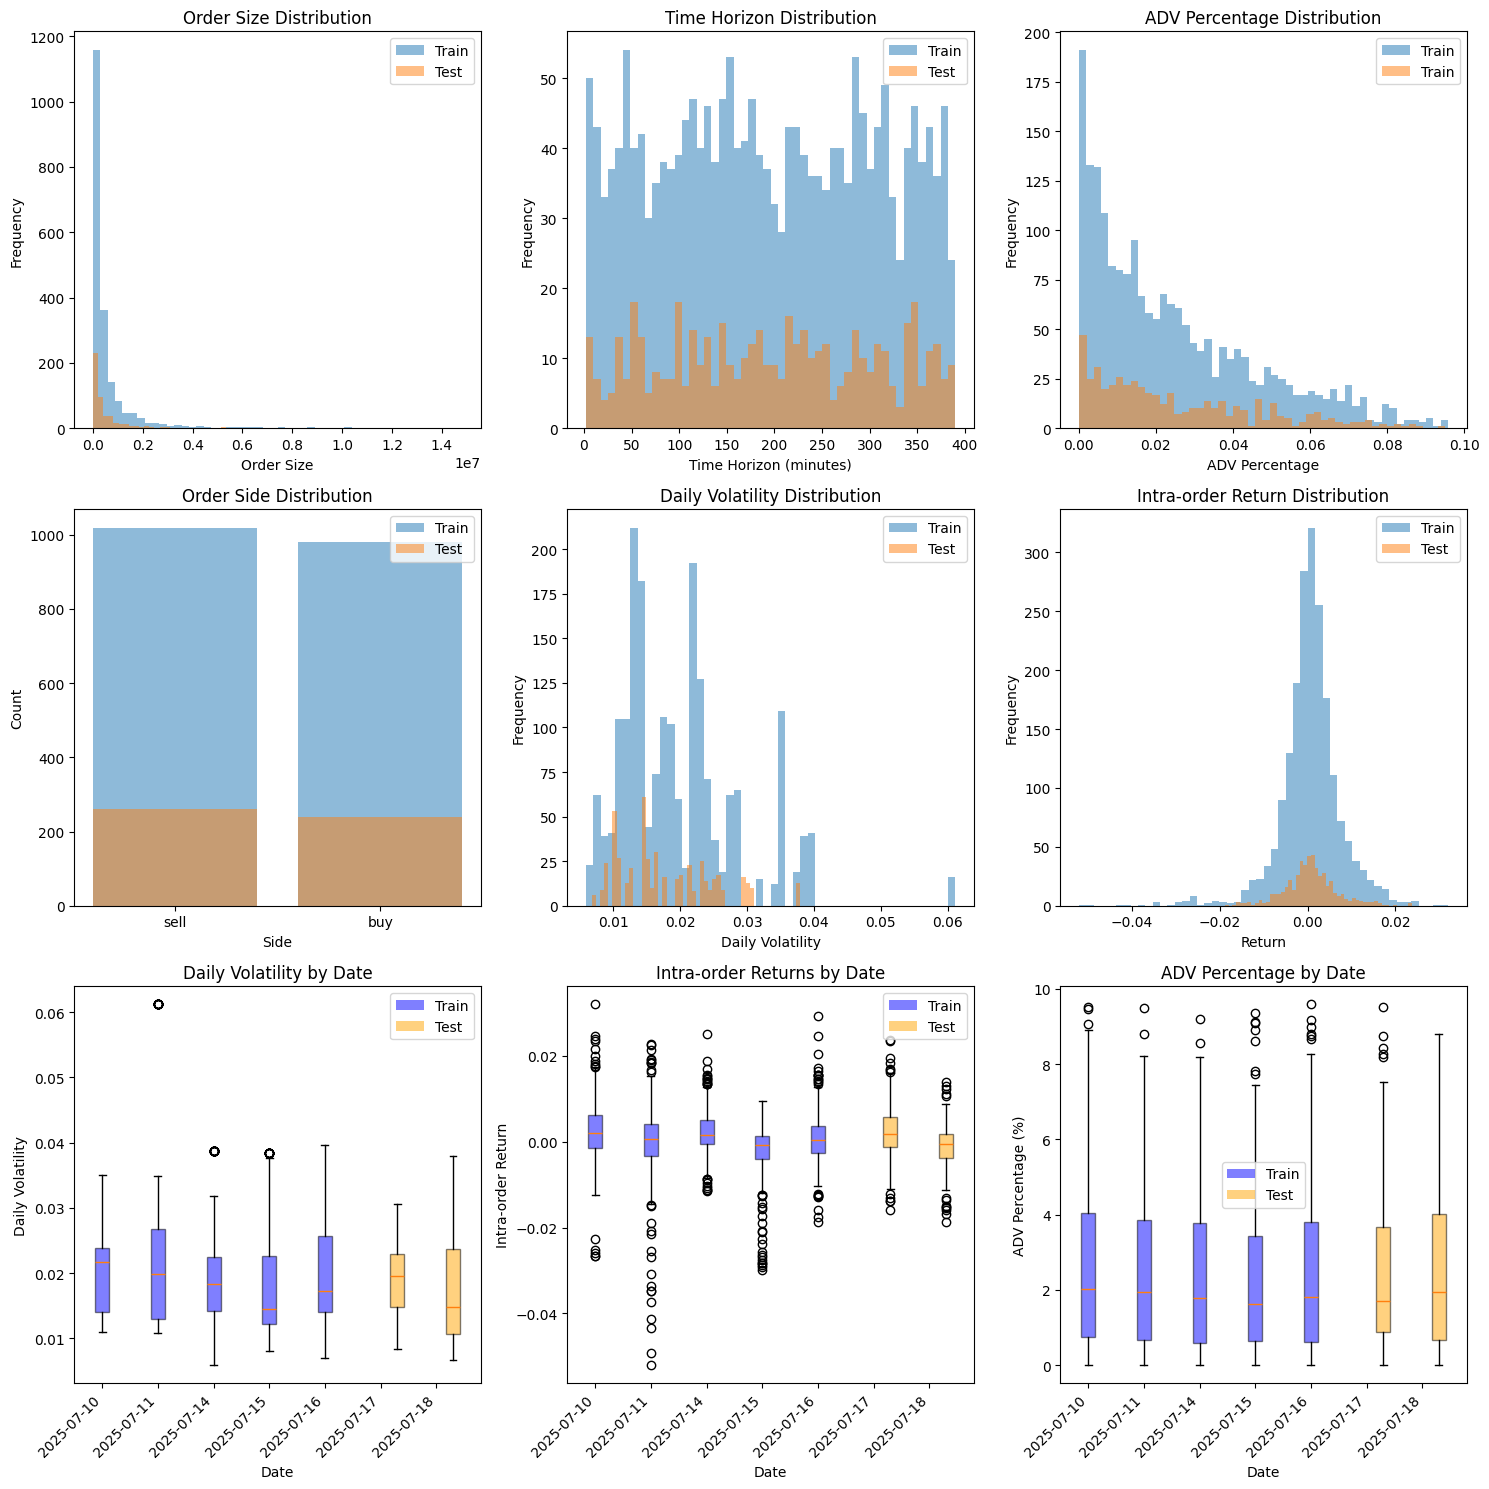


Sample train orders with dates:
  ticker       date  start_time  end_time  order_qty  side
0   ADBE 2025-07-10         270       374      66619   buy
1   AAPL 2025-07-10          71       179     502775   buy
2   NVDA 2025-07-10          20       210    7414577  sell
3   TSLA 2025-07-10         121       225    1642268   buy
4   INTC 2025-07-10          74       290     433497   buy

Sample test orders with dates:
  ticker       date  start_time  end_time  order_qty  side
0   ADBE 2025-07-17         270       374      53405   buy
1   AAPL 2025-07-17          71       179     180959  sell
2   NVDA 2025-07-17          20       210    2460743   buy
3   TSLA 2025-07-17         121       225     923532  sell
4   INTC 2025-07-17          74       290    1355371  sell


In [4]:
# print orders dataframe in single line per order
rp.display_order_info(train_orders_df, name='Sample Train', num_orders=3)
rp.display_order_info(test_orders_df, name='Sample Test', num_orders=3)
rp.plot_order_histograms(train_orders_df, test_orders_df)

# Show sample orders with dates
print("\nSample train orders with dates:")
print(train_orders_df[['ticker', 'date', 'start_time', 'end_time', 'order_qty', 'side']].head(5))
print("\nSample test orders with dates:")
print(test_orders_df[['ticker', 'date', 'start_time', 'end_time', 'order_qty', 'side']].head(5))


**RL Environment**

In the current setup the agent’s **state** at each step is a 14-dimensional real vector  
$$
s_t = \bigl[p_t^{\rm mid},\,V_t,\,T - t,\,q_t,\,\alpha,\,x,\,f,\,m,\,\delta,\,A,\,p_0,\,r,\,v^{(1)},\,v^{(5)}\bigr],
$$  
where it sees the current mid-price, market volume, time and shares remaining, target participation rate, trading signals, last fill and trade stats, arrival price, regime and short/long‐term volatilities.  Its **action**  
$$
a_t \in \{-1.0,\,-0.75,\, -0.5,\,-0.25,\,-0.1,\,0,\,0.10,\,0.15,\,0.25,\,0.50,\,0.75,\ 1.0\}
$$  
is “accelerate or decelerate versus the constant rate to trade this fraction of today’s volume,” so the env executes  
$$
\Delta q_t = \min(\rho_i(1 + a_t)\,V_t,\;q_t)
$$  
shares (and updates  
$$
q_{t+1} = q_t - \Delta q_t
$$  

$$\rho_i = \frac{Q_i}{V[t_{start}, t_{end}]}$$ 
and the running VWAP).  Episodes end when either all shares are filled or the time horizon is hit, a large penalty is applied if the order does not complete.


**Trading Simulation**

In order to realistically simulate market behaviour, each trade needs to create an impact on price, and successive trades must propagate impact to the next order and so on. Rather than consider the nuance of trade by trade, limit and market orders and order books which require many assumptions and complex limit order book simulators, we focus on minutely percentage of volume trading. This allows to focus on building an optimal scheduling algorithm and removes the granular complexities of limit order books, order types and venue types.

For minutely impact level impact estimations have utilized the transient impact model 2 from Bouchaud's book Trades, Quotes and Prices [7] which is parameterized with intuitive default values for this update and assumes the 1 minute trade impact follows square root.  We account for gaps between 1 minute trade intervals allowing for more accurate decay. In the final report, we will include a calibrated version of this model based on the trades observed via Bank of America's trade data. 


**Linear Transient‐Impact (Propagator) Model [7]**  
$$
r_t \;=\;\sum_{t'<t} G(t - t')\,\epsilon_{t'} \;+\;\eta_t,
$$
where $r_t = P_t - P_{t-1}$ is the mid-price return, $\epsilon_{t'}\!=\pm1$ the sign of the trade at time $t'$, $G(\tau)$ the propagator kernel, and $\eta_t$ an uncorrelated noise term.  

In our case we do allow for non-uniformity of time steps between trades so we modify to consider the $t_{\Delta}$:

$$
\lambda(\Delta t)
\;=\;
\exp\!\Bigl(-\frac{\Delta t}{\tau}\Bigr),
\quad
\Delta I_t
\;=\;
Y\,\sigma\,\sqrt{\frac{q_t}{V}},
$$

$$
I_t
\;=\;
\lambda(\Delta t)\,I_{t-1}
\;+\;
\Delta I_t,
$$

$$
p_t^{\mathrm{fill}}
\;=\;
p_t^{\mathrm{vwap}}
\bigl(1 \;+\; s\,I_t\bigr).
$$

In [5]:
# Create vectorized execution environments for training
print("Creating vectorized training environment...")

print("Creating CPU training environment...")

# Use the new vectorized environment with wrapper for training

train_execution_cpu_env = VectorizedMultiOrderExecutionEnv(
    stock_df_list=stock_df_list,
    orders_df=train_orders_df,
    impact_coef=1,
    decay_rate=5,
    num_envs=num_vec_envs_cpu,  
    min_rate=0,
    max_rate=max_trading_rate,
    device='cpu',
    seed=fixed_seed
)


max_horizon = int(train_orders_df["time_horizon"].max())

# Check environment
print("✓ Vectorized cpu train environment check passed!")


# Create vectorized execution environments for testing (direct access for execution)
print("\nCreating vectorized cpu test environment...")


test_execution_cpu_env = VectorizedMultiOrderExecutionEnv(
    stock_df_list=stock_df_list,
    orders_df=test_orders_df,
    impact_coef=1,
    decay_rate=5,
    num_envs=num_vec_envs_cpu,  
    min_rate=0,
    max_rate=max_trading_rate,
    device='cpu',
    seed=fixed_seed
)


print("✓ Vectorized cpu test environment check passed!")

# for compatibility with training environment, create a GPU (if available) and CPU environment
if device in ["cuda", "mps"]:
    
    train_execution_gpu_env = VectorizedMultiOrderExecutionEnv(
        stock_df_list=stock_df_list,
        orders_df=train_orders_df,
        impact_coef=1,
        decay_rate=5,
        num_envs=num_vec_envs_gpu,  
        min_rate=0,
        max_rate=max_trading_rate,
        device=device,
        seed=fixed_seed
    )


    print("✓ Using VectorizedMultiOrderExecutionEnv with training wrapper for GPU for training")
    # Create vectorized execution environments for testing (direct access for execution)
    print("\nCreating vectorized gpu test environment...")
 
    test_execution_gpu_env = VectorizedMultiOrderExecutionEnv(
        stock_df_list=stock_df_list,
        orders_df=test_orders_df,
        impact_coef=1,
        decay_rate=5,
        num_envs=num_vec_envs_gpu,  
        min_rate=0,
        max_rate=max_trading_rate,
        device=device,
        seed=fixed_seed
    )
    
    print("✓ Vectorized gpu test environment check passed!")

else:
    print("No GPU available, using CPU for training and testing")
    train_execution_gpu_env = train_execution_cpu_env
    test_execution_gpu_env = test_execution_cpu_env


print(f"\nVectorized Environment Summary:")
print(f"  - Training orders: {len(train_orders_df)}")
print(f"  - Test orders: {len(test_orders_df)}")
print(f"  - Vectorized environments: GPU: {num_vec_envs_gpu} and CPU: {num_vec_envs_cpu}")
print(f"  - Max horizon: {max_horizon} steps")
if device in ["cuda", "mps"]:
    print(f"  - Device: {device} + CPU")
else:
    print(f"  - Device: cpu")


Creating vectorized training environment...
Creating CPU training environment...
2025-07-19 09:53:04 - optimal_execution_env_vectorized - INFO - Using device: cpu (explicitly set)
✓ Vectorized cpu train environment check passed!

Creating vectorized cpu test environment...
2025-07-19 09:53:04 - optimal_execution_env_vectorized - INFO - Using device: cpu (explicitly set)
✓ Vectorized cpu test environment check passed!
2025-07-19 09:53:04 - optimal_execution_env_vectorized - INFO - Using device: cuda (explicitly set)
✓ Using VectorizedMultiOrderExecutionEnv with training wrapper for GPU for training

Creating vectorized gpu test environment...
2025-07-19 09:53:04 - optimal_execution_env_vectorized - INFO - Using device: cuda (explicitly set)
✓ Vectorized gpu test environment check passed!

Vectorized Environment Summary:
  - Training orders: 2000
  - Test orders: 500
  - Vectorized environments: GPU: 64 and CPU: 256
  - Max horizon: 390 steps
  - Device: cuda + CPU


In [ ]:
# Set up vectorized model parking and train a simple model
mp_vec = mp.ModelParking()

num_orders_per_episode = 5000
num_train_steps = 390/2 * num_orders_per_episode


# Memory cleanup before training
if device != 'cpu':
    torch.cuda.empty_cache() if device == 'cuda' else None
    gc.collect()
    print("GPU memory cleaned")

# Train a simple vectorized PPO model
model_name = "ppo_multiorder_exec_vec"
print(f"\nTraining model: {model_name}")
start_time = time.time()

model = PPO(
    "MlpPolicy", 
    train_execution_cpu_env, 
    device="cpu",  # Use CPU for training 
    verbose=1,  # Show progress
    learning_rate=1e-4, 
    n_steps=32,  
    batch_size=batch_size,     
    n_epochs=4,
    gamma=0.999, 
    gae_lambda=0.95, 
    clip_range=0.1,
    tensorboard_log='./tensorboard_logs/',
    policy_kwargs=dict(
        net_arch=dict(pi=[256, 256], vf=[256, 256]), 
        activation_fn=torch.nn.ReLU
    )
)

print(f"Training {model_name} for {num_train_steps} steps...")
mp_vec.park_model(model, model_name, learn=True, steps=num_train_steps, save=True)
train_time = time.time() - start_time
print(f"Model {model_name} trained in {train_time:.2f} seconds")

# Add baseline strategies
print("\nSetting up baseline strategies...")
vwap_model = bs.VWAPBaseline()
mp_vec.park_model(vwap_model, "vwap_baseline_vec", learn=False, save=False)

random_model = bs.RandomBaseline(seed=fixed_seed)
mp_vec.park_model(random_model, "random_baseline_vec", learn=False, save=False)


2025-07-19 10:15:25 - root - INFO - ModelParking initialized without cached models.
GPU memory cleaned

Training model: ppo_multiorder_exec_vec
Using cpu device
Training ppo_multiorder_exec_vec for 9750000.0 steps...
Logging to ./tensorboard_logs/PPO_3
-------------------------------
| time/              |        |
|    fps             | 59510  |
|    iterations      | 1      |
|    time_elapsed    | 4      |
|    total_timesteps | 262144 |
-------------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 2053        |
|    iterations           | 2           |
|    time_elapsed         | 255         |
|    total_timesteps      | 524288      |
| train/                  |             |
|    approx_kl            | 0.016473014 |
|    clip_fraction        | 0.0343      |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.122      |
|    explained_variance   | -1.16       |
|    learning_rate 

In [ ]:
# Force CPU as it trains significantly faster

class ExecFeatures(BaseFeaturesExtractor):
    def __init__(self, observation_space, features_dim=512):
        super().__init__(observation_space, features_dim)

        self.trunk = nn.Sequential(
            nn.LayerNorm(observation_space.shape[0]),
            nn.Linear(observation_space.shape[0], 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU()
        )

        # Temporal Convolutional Network (causal, dilation 1–2)
        self.tcn = nn.Sequential(
            nn.Conv1d(512, 256, kernel_size=3, padding=2, dilation=1),
            nn.ReLU(),
            nn.Conv1d(256, 256, kernel_size=3, padding=4, dilation=2),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten()
        )

        # calculate output size after TCN: 256 × 512? (kernel pad chosen so length stays 1)
        self._features_dim = 256  # final channel count

    def forward(self, obs):
        x = self.trunk(obs)
        x = x.unsqueeze(-1)       # [B, 512, 1]
        x = self.tcn(x)
        return x                  # shape [B, 256]

policy_kwargs = dict(
    features_extractor_class=ExecFeatures,
    features_extractor_kwargs=dict(features_dim=256),
    net_arch=dict(pi=[256], vf=[256]),   # heads
    activation_fn=nn.ReLU
)

model_name = "ppo_cnn_multiorder_exec_vec_cpu"
print(f"\nTraining model: {model_name}")
start_time = time.time()

model = PPO(
    policy="MlpPolicy",
    env=train_execution_cpu_env,                 
    device="cpu",
    n_steps=1024, 
    batch_size=256,              
    learning_rate=1e-4,
    n_epochs=4,                  # fewer because batches are large
    clip_range=0.1,
    gae_lambda=0.95,
    gamma=0.999,
    verbose=1,
    tensorboard_log='./tensorboard_logs/',
    policy_kwargs=policy_kwargs,
)
num_train_steps_cnn = 390/2 * num_orders_per_episode 

print(f"Training configuration:")
print(f"Training {model_name} for {num_train_steps_cnn} steps on device CPU...")
print(f"  - Parallel environments: {train_execution_cpu_env.num_envs}")
print(f"  - Effective rollout size: {model.n_steps * train_execution_cpu_env.num_envs}")
print(f"  - Batch size: {model.batch_size}")
print(f"  - Device: {model.device}")
print(f"  - Expected speedup: ~{train_execution_cpu_env.num_envs}x")


mp_vec.park_model(model, model_name, learn=True, steps=num_train_steps_cnn, save=True)
train_time = time.time() - start_time

print(f"Model {model_name} trained in {train_time:.2f} seconds")
print("Models ready for testing")




Training model: ppo_cnn_multiorder_exec_vec_cpu
Using cpu device
Training configuration:
Training ppo_cnn_multiorder_exec_vec_cpu for 9750000.0 steps on device CPU...
  - Parallel environments: 256
  - Effective rollout size: 262144
  - Batch size: 256
  - Device: cpu
  - Expected speedup: ~256x
Logging to ./tensorboard_logs/PPO_4
-------------------------------
| time/              |        |
|    fps             | 26372  |
|    iterations      | 1      |
|    time_elapsed    | 9      |
|    total_timesteps | 262144 |
-------------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 4344        |
|    iterations           | 2           |
|    time_elapsed         | 120         |
|    total_timesteps      | 524288      |
| train/                  |             |
|    approx_kl            | 0.011351898 |
|    clip_fraction        | 0.000623    |
|    clip_range           | 0.5         |
|    entropy_loss     

KeyboardInterrupt: 

In [10]:
# CONSISTENT VECTORIZED ORDER EXECUTION WITH PERFORMANCE TRACKING

import optimal_execution_env_vectorized 

print("="*80)
print("All models will execute the same orders")
print("="*80)

model_name_list = mp_vec.list_models()
print(f"Available models: {model_name_list}")



num_episodes = 20  
execution_times = {}
test_orders = {}

print(f"All {len(model_name_list)} models will execute the same {num_episodes} orders for fair comparison.")
print("="*80)

# Manual consistent comparison approach
common_order_indices = None
i = 0

for model_name in model_name_list:

    model = mp_vec.get_model(model_name)
    
    
    # Use vectorized execution (same interface as original environment)
    # if device attribute exists and is in ["cuda", "mps"] then use the gpu environment
    # otherwise use the cpu environment
    if "ppo" in model_name and model.device in ["cuda", "mps"]:
        print(f"Using GPU environment for {model_name}")
        test_execution_env = test_execution_gpu_env
    else:
        print(f"Using CPU environment for {model_name}")
        test_execution_env = test_execution_cpu_env
        model.device = "cpu"

    print(f"\n{'='*60}")
    print(f"Executing orders with model: {model_name} with device: {model.device} ({i+1}/{len(model_name_list)})")
    print(f"{'='*60}")
    
    start_time = time.time()
    
    if i == 0:
        # First model establishes the order set
        print(f"Establishing order set with {model_name}...")
        orders, order_indices = test_execution_env.execute_orders( 
            model=model, 
            num_episodes=num_episodes
        )
        common_order_indices = order_indices
        test_orders[model_name] = orders
        print(f"Using order indices: {common_order_indices[:5]}...{common_order_indices[-5:]} (showing first/last 5)")
        
    else:
        # Subsequent models use the same orders
        if common_order_indices is not None:
            print(f"Using same order set as first model...")
            orders = test_execution_env.execute_fixed_orders(
                model=model, 
                order_indices=common_order_indices
            )
            test_orders[model_name] = orders
        else:
            print(f"Using standard execution (no common indices available)...")
            orders = test_execution_env.execute_orders(model=model, num_episodes=num_episodes)
            test_orders[model_name] = orders
    
    exec_time = time.time() - start_time
    execution_times[model_name] = exec_time
    
    print(f"Execution completed in {exec_time:.2f} seconds")
    print(f"Average time per episode: {exec_time/num_episodes:.3f} seconds")
    
    # Memory cleanup between models
    if device != 'cpu':
        torch.cuda.empty_cache() if device == 'cuda' else None
        gc.collect()

    i += 1

print(f"\nEXECUTION COMPLETED!")
if common_order_indices is not None:
    print(f"All {len(model_name_list)} models executed the same {len(common_order_indices)} orders for fair comparison!")
    print(f"Order indices used: {common_order_indices}")
else:
    print("Using fallback method - orders may not be identical across models.")
    print("Consider checking the implementation of execute_orders method.")

print(f"\n{'='*60}")
print("VECTORIZED EXECUTION SUMMARY")
print(f"{'='*60}")
total_time = sum(execution_times.values())
for model_name, exec_time in execution_times.items():
    print(f"{model_name:30}: {exec_time:6.2f}s ({exec_time/num_episodes:.3f}s/episode)")
print(f"{'Total execution time':30}: {total_time:6.2f}s")
print(f"{'Average per model':30}: {total_time/len(execution_times):6.2f}s")


All models will execute the same orders
Available models: ['ppo_multiorder_exec_vec', 'vwap_baseline_vec', 'random_baseline_vec', 'ppo_cnn_multiorder_exec_vec_cpu']
All 4 models will execute the same 20 orders for fair comparison.
Using CPU environment for ppo_multiorder_exec_vec

Executing orders with model: ppo_multiorder_exec_vec with device: cpu (1/4)
Establishing order set with ppo_multiorder_exec_vec...
Using order indices: [123, 481, 482, 103, 142]...[72, 379, 258, 26, 279] (showing first/last 5)
Execution completed in 19.05 seconds
Average time per episode: 0.953 seconds
Using CPU environment for vwap_baseline_vec

Executing orders with model: vwap_baseline_vec with device: cpu (2/4)
Using same order set as first model...
Execution completed in 11.33 seconds
Average time per episode: 0.567 seconds
Using CPU environment for random_baseline_vec

Executing orders with model: random_baseline_vec with device: cpu (3/4)
Using same order set as first model...
Execution completed in 11

Generating vectorized analysis...

=== Plotting orders for ppo_multiorder_exec_vec ===


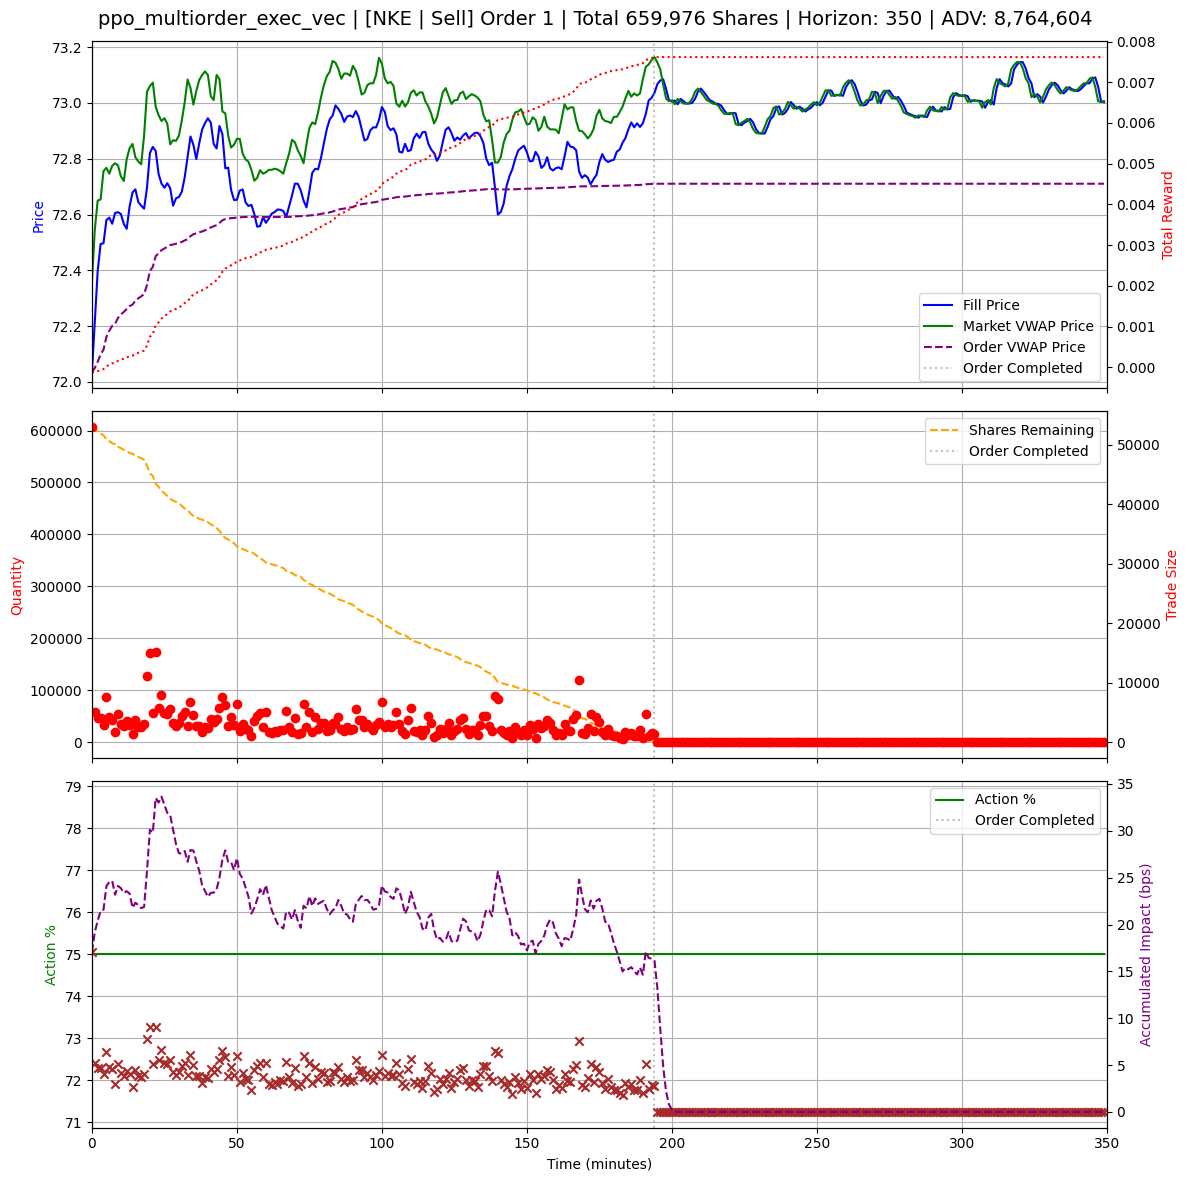

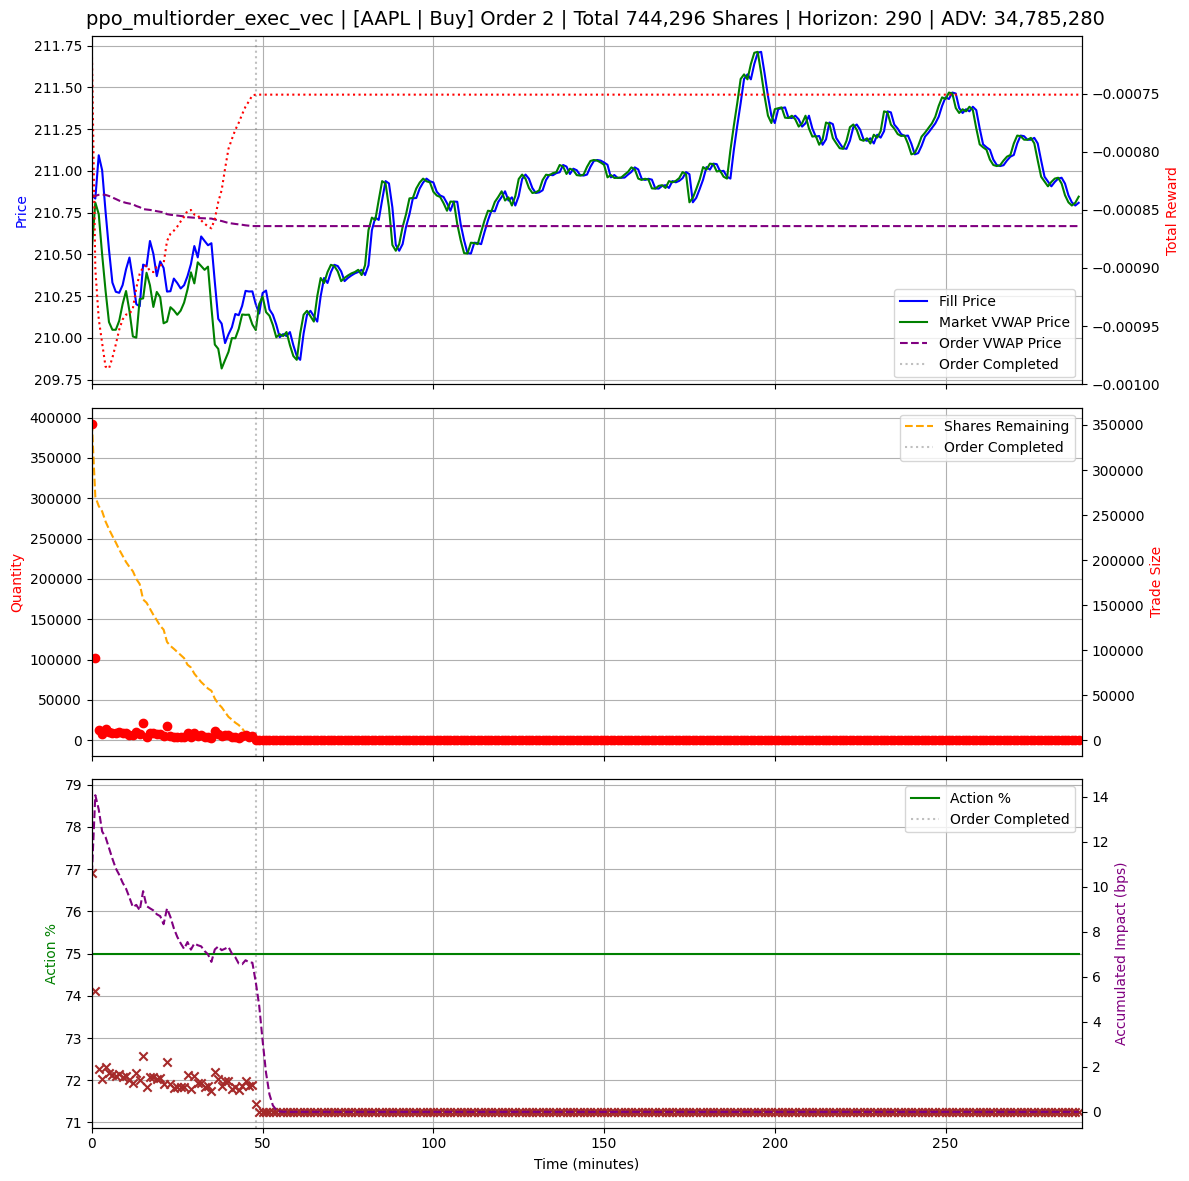

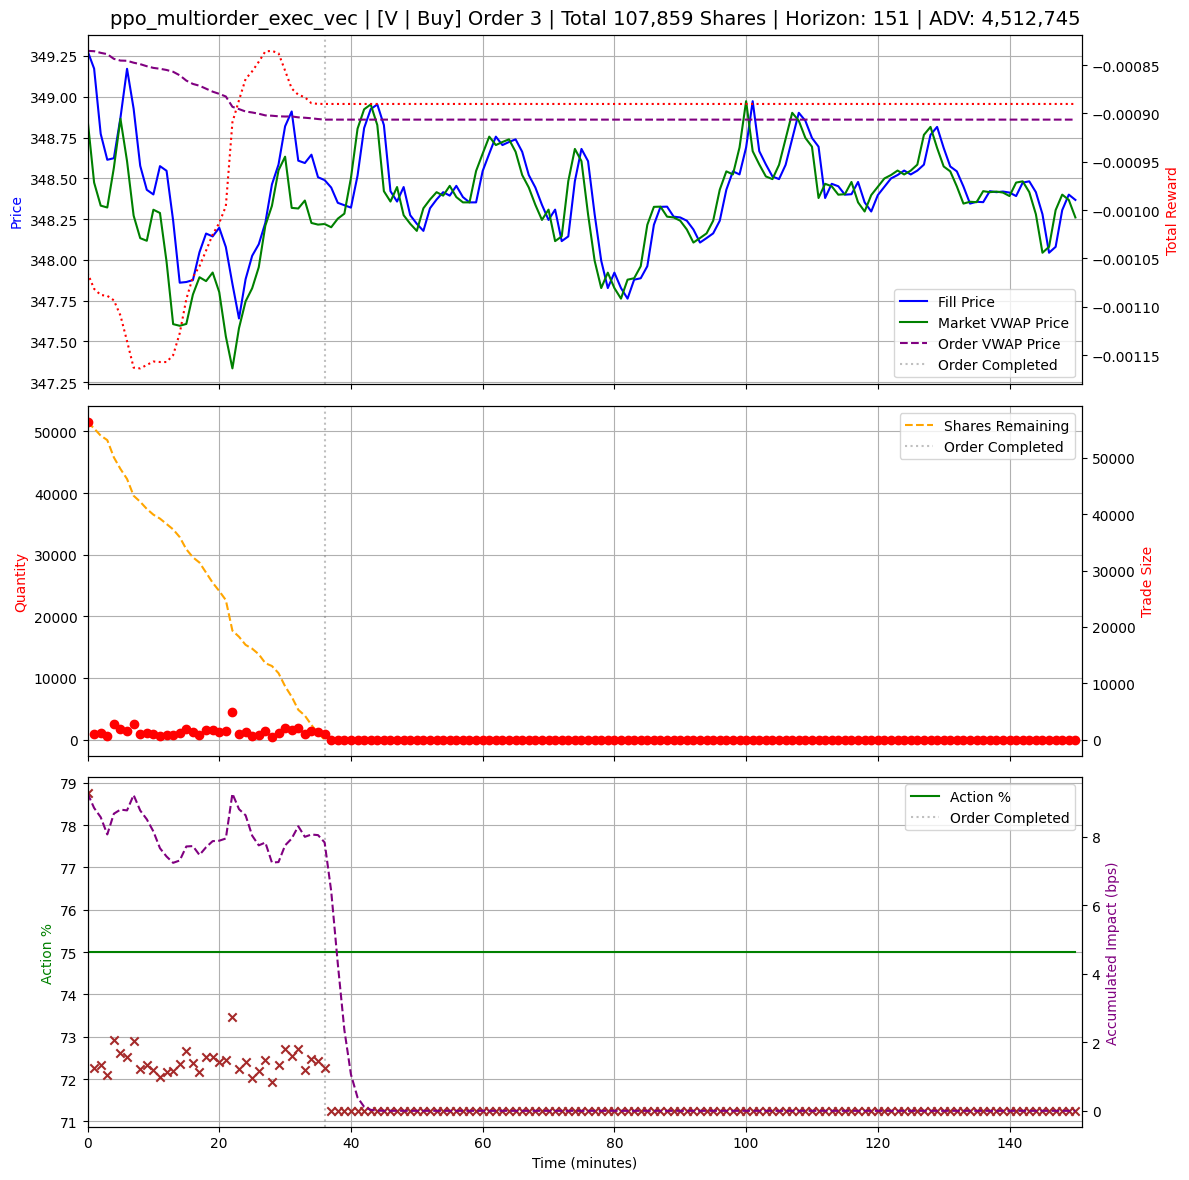


=== Plotting orders for vwap_baseline_vec ===


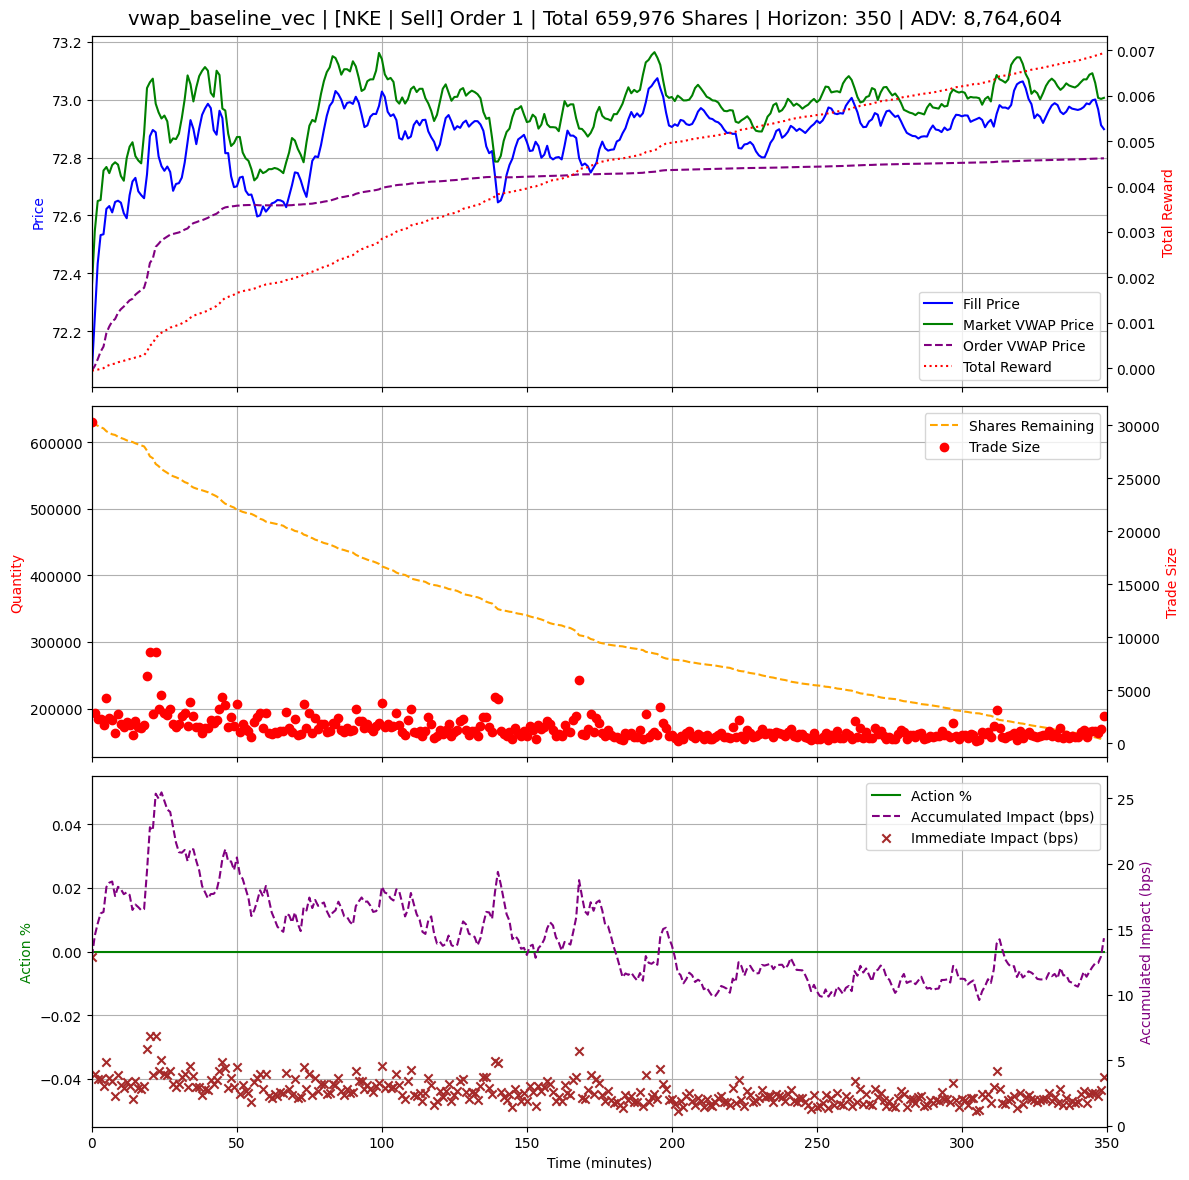

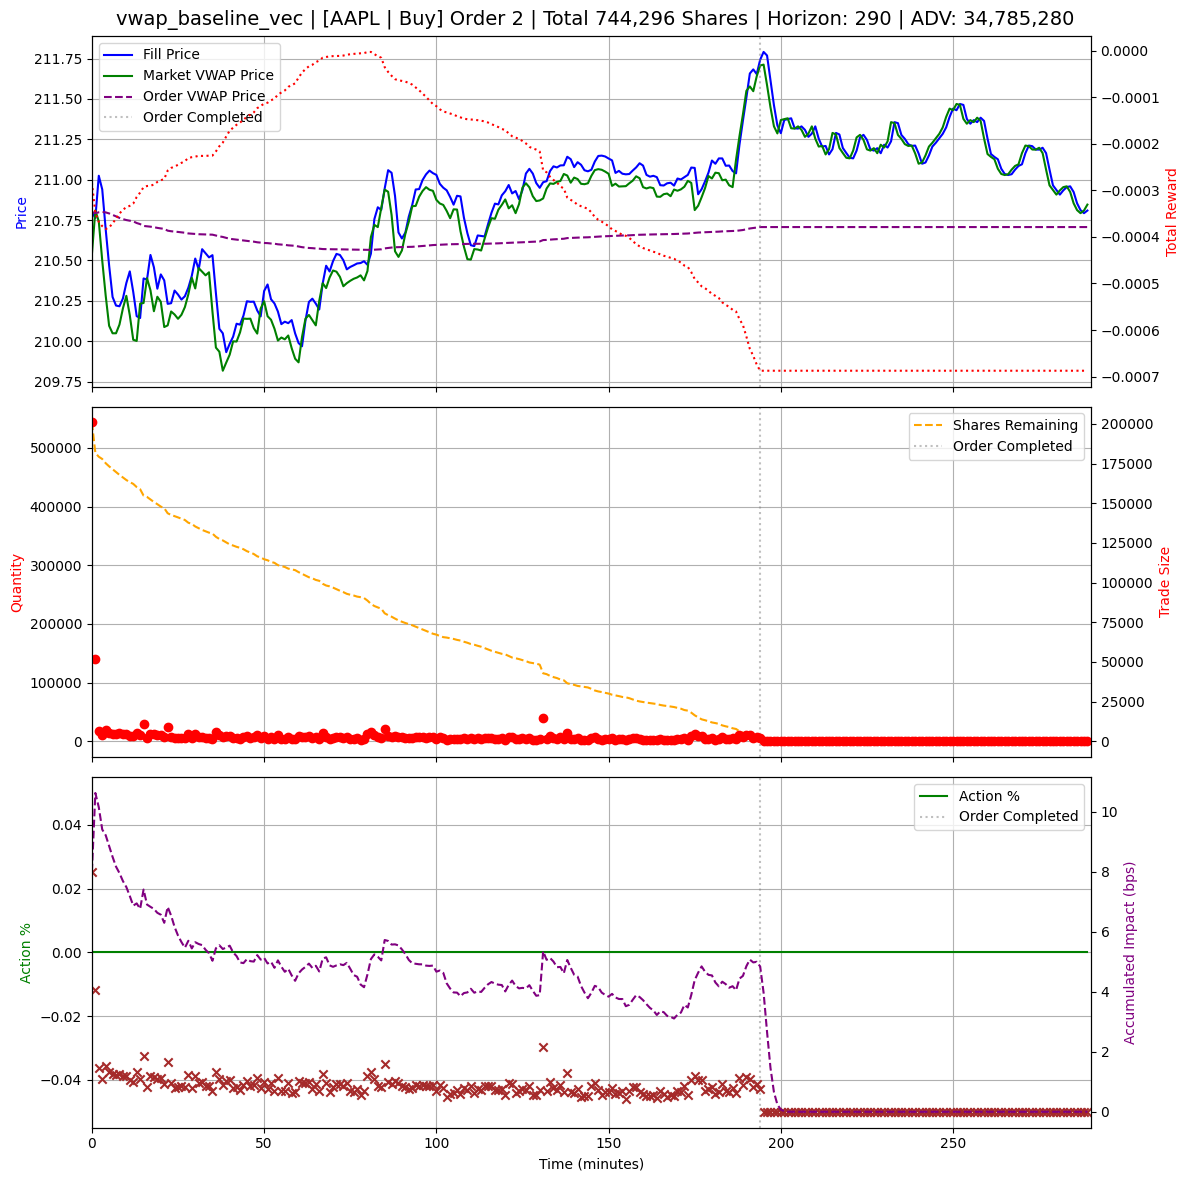

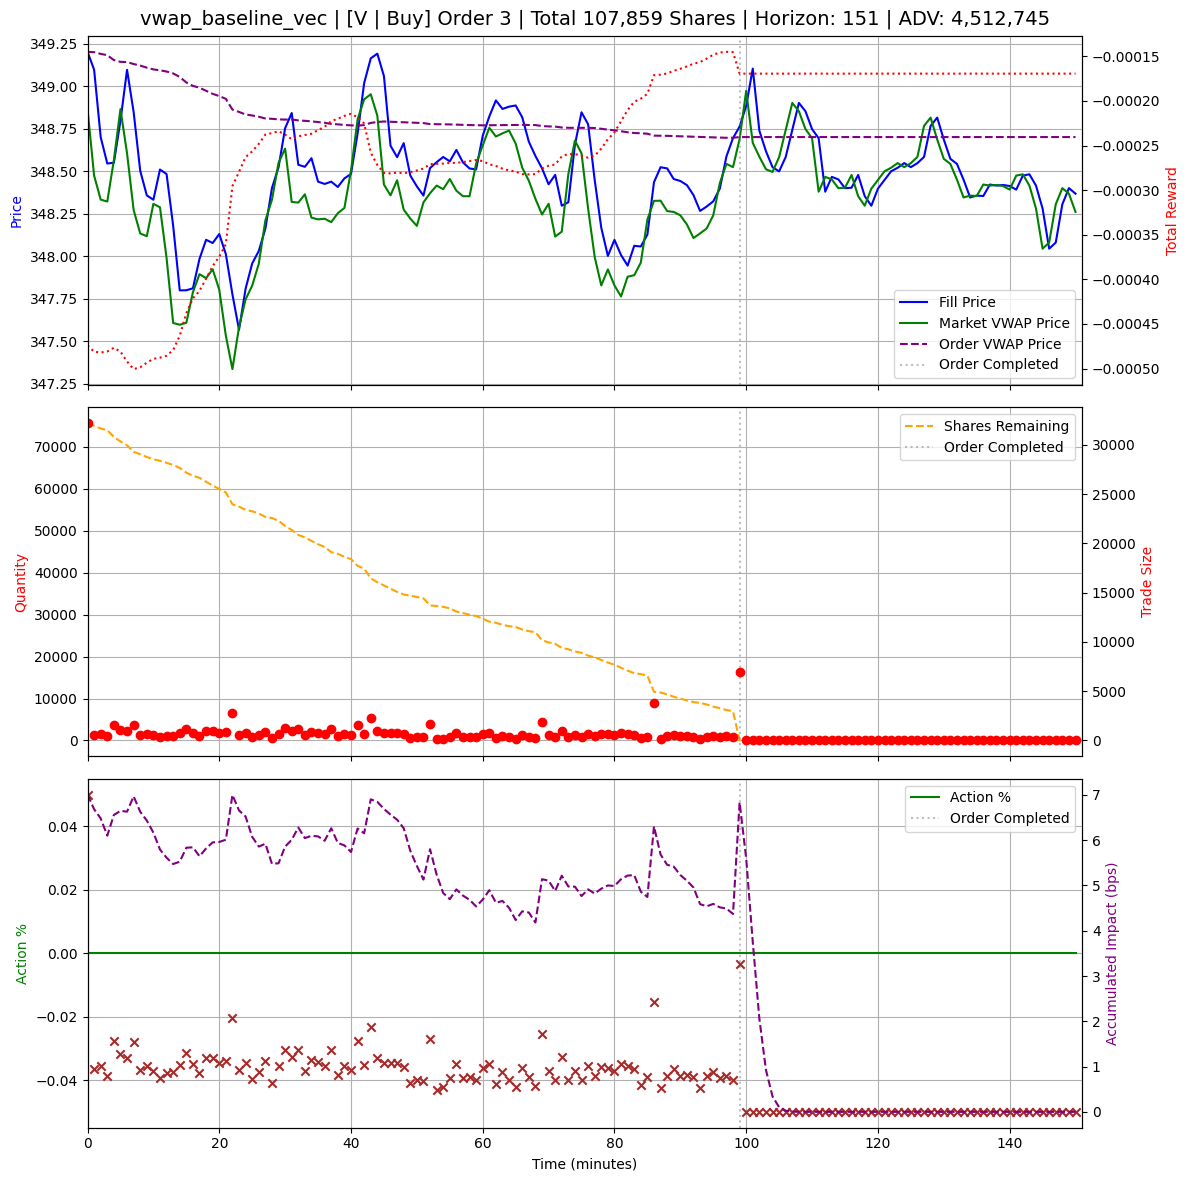


=== Plotting orders for random_baseline_vec ===


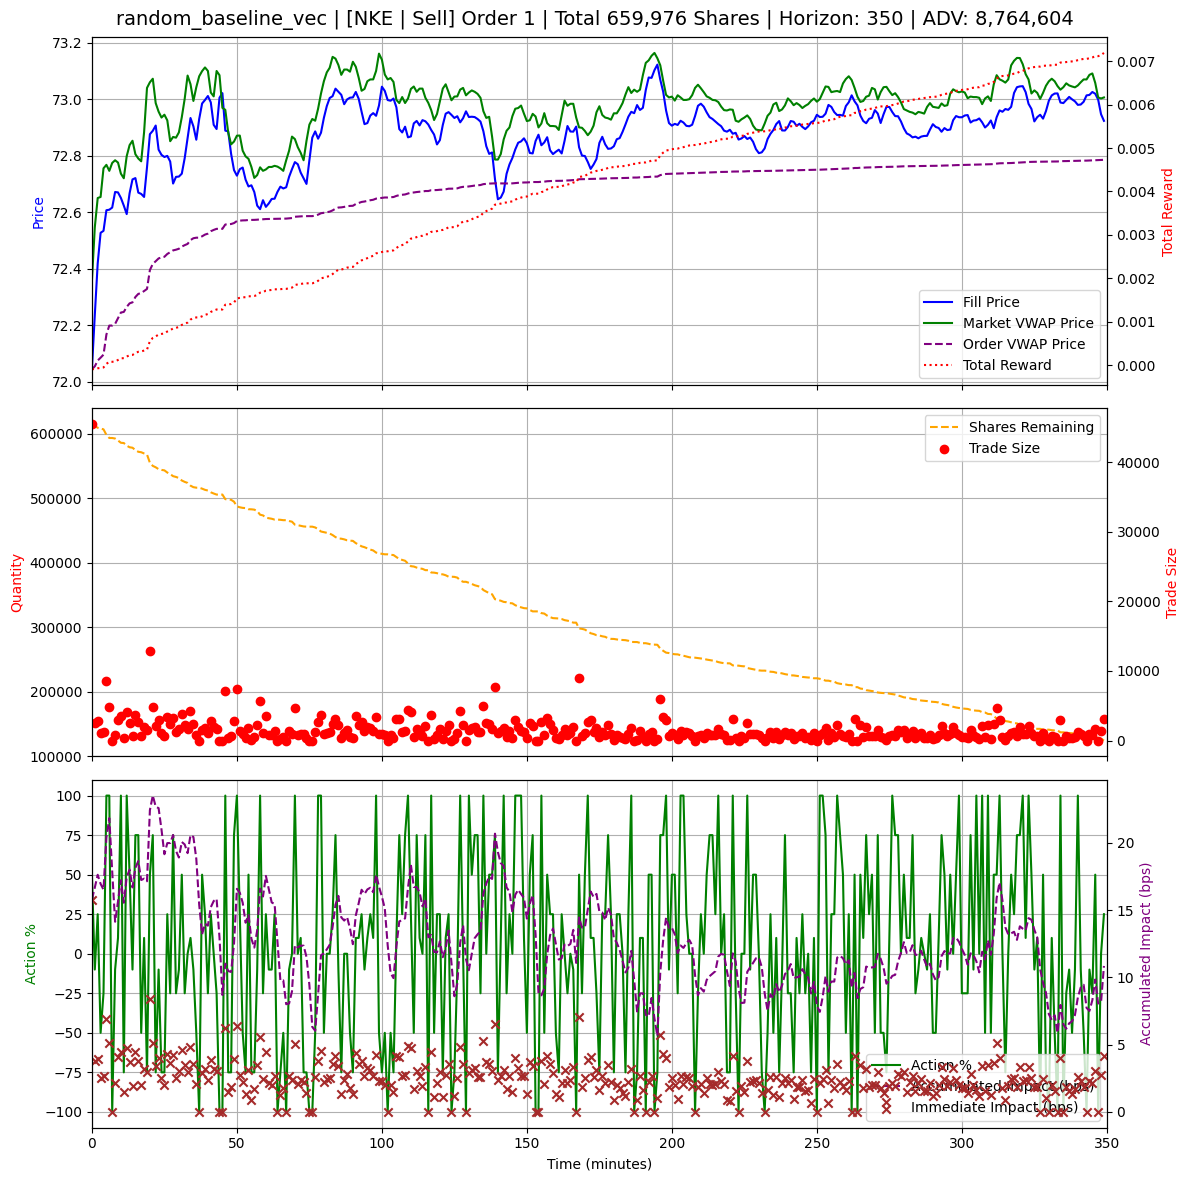

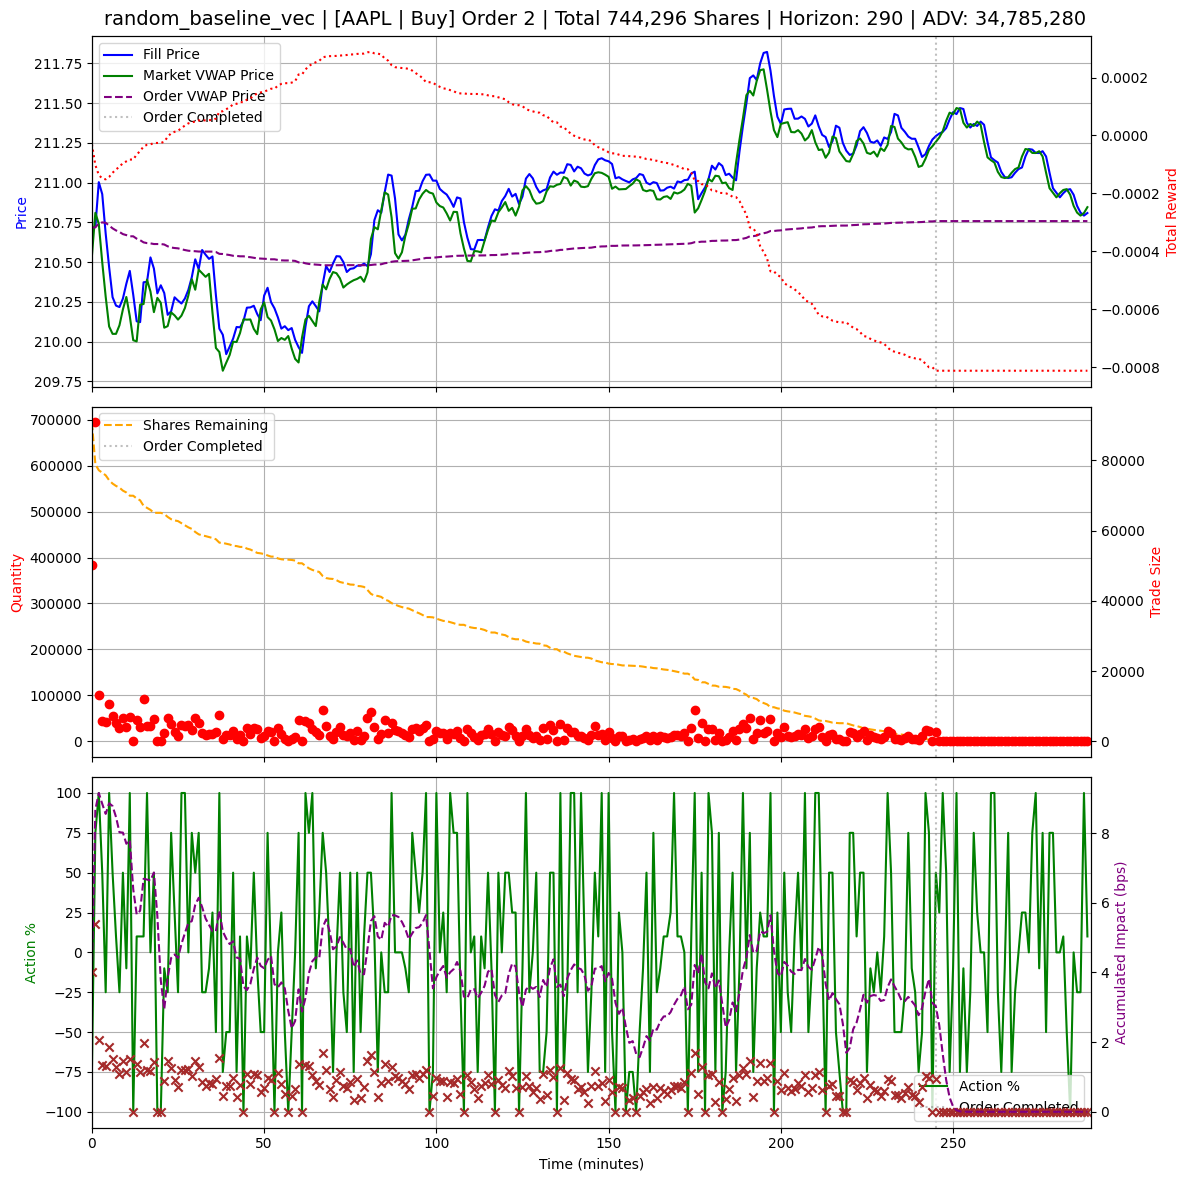

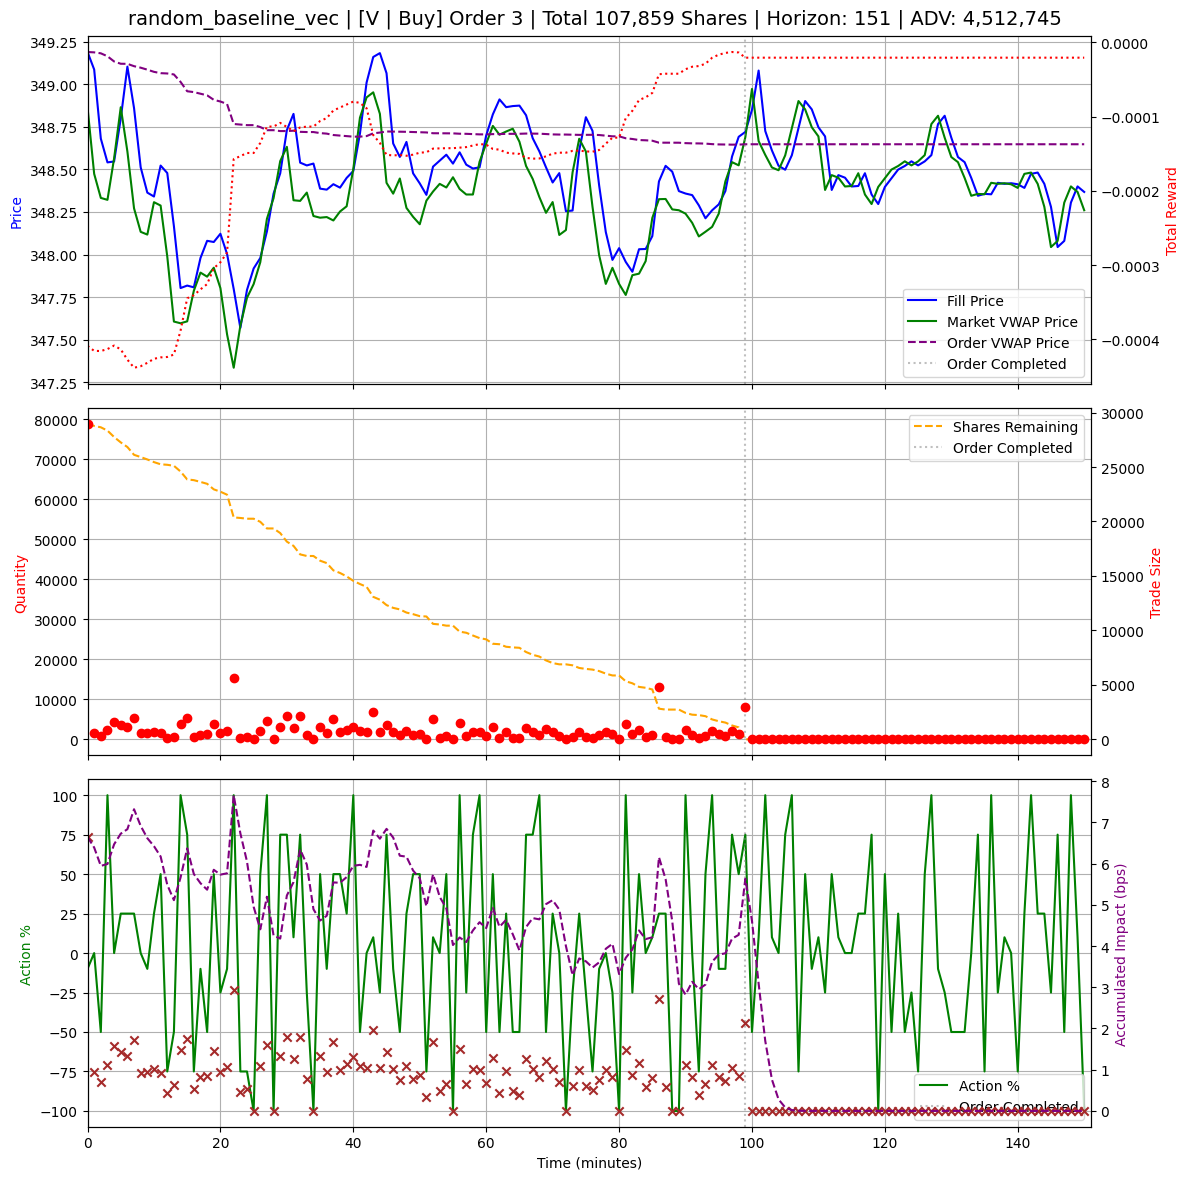


=== Plotting orders for ppo_cnn_multiorder_exec_vec_cpu ===


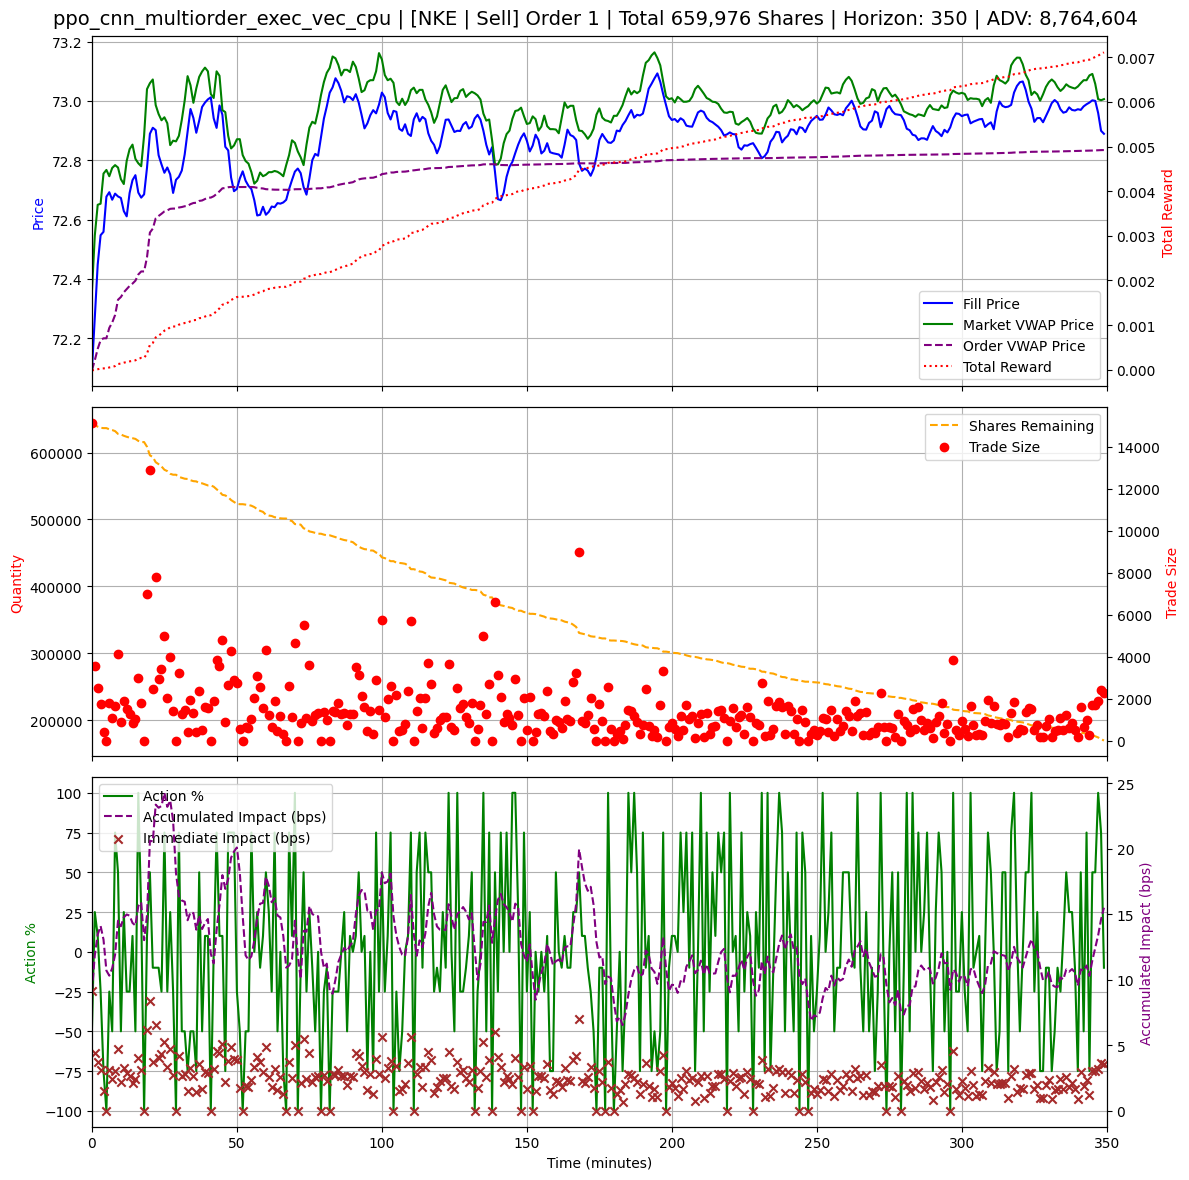

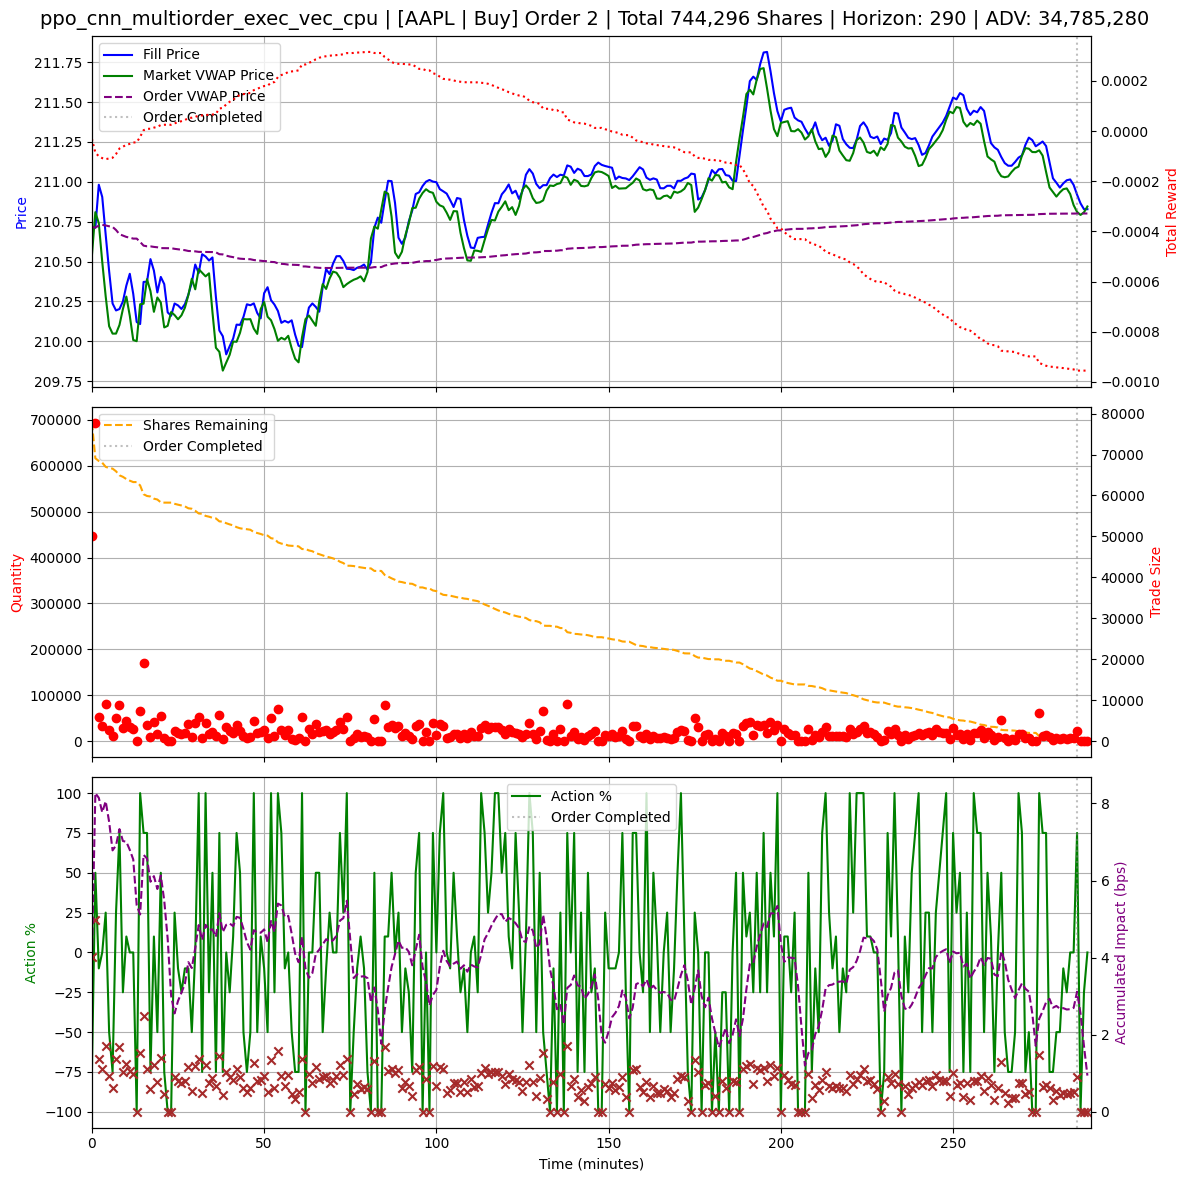

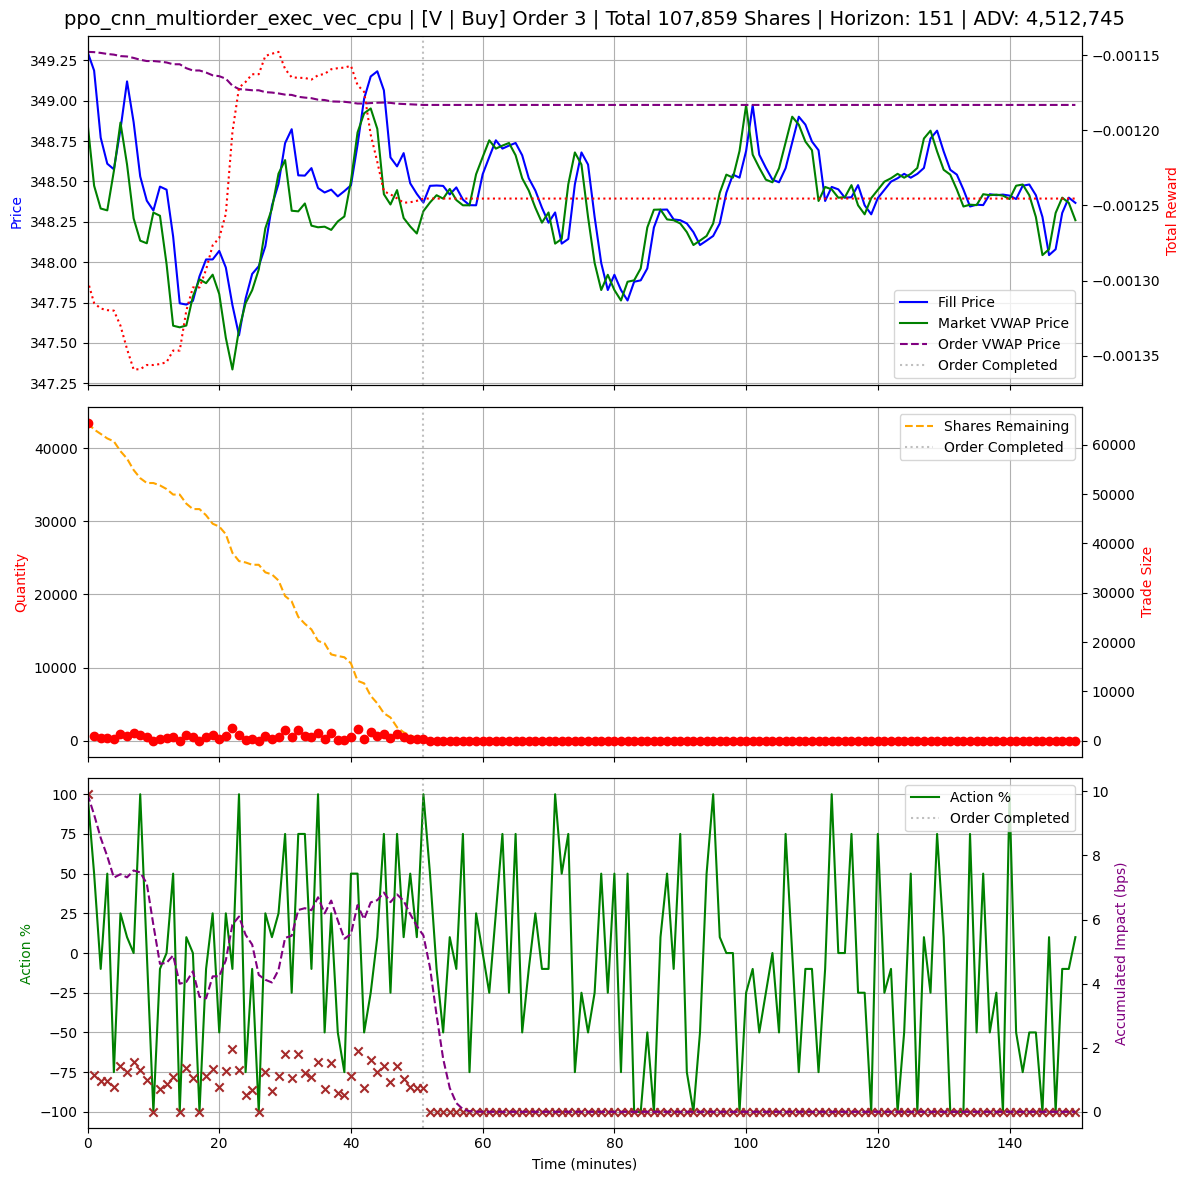


Vectorized Test Environment Results:

Execution Summary Table
Number of Orders - ppo_multiorder_exec_vec: 20 | vwap_baseline_vec: 20 | random_baseline_vec: 20 | ppo_cnn_multiorder_exec_vec_cpu: 20
Slippage trimmed (top/bottom 1.0% by notional weight)
--------------------------------------------------------------------------------------------------------------------------------------------------------------
Metric                        ppo_multiorder_exec_vec ppo_multiorder_exec_vec Stdvwap_baseline_vec vwap_baseline_vec Stdrandom_baseline_vec random_baseline_vec Stdppo_cnn_multiorder_exec_vec_cpu ppo_cnn_multiorder_exec_vec_cpu Std
--------------------------------------------------------------------------------------------------------------------------------------------------------------
Weighted Slippage (bps)                -96.72           53.60         -96.81           61.19        -100.06           62.32         -97.15           63.47
Weighted Duration Ratio                  0.2

In [12]:
# Vectorized plotting and analysis

print("Generating vectorized analysis...")
start_time = time.time()

# Plot execution results
rp.plot_orders(test_orders, num_orders=3)

# Create comprehensive summary tables
print("\nVectorized Test Environment Results:")
print("="*80)
rp.create_execution_summary_table(orders_dict=test_orders, trim=0.01)

analysis_time = time.time() - start_time
print(f"\nAnalysis completed in {analysis_time:.2f} seconds")

# Performance comparison and system metrics
print("\nVECTORIZED PERFORMANCE SUMMARY")
print("="*80)

# Calculate performance metrics
total_episodes = len(model_name_list) * num_episodes
total_execution_time = sum(execution_times.values())
avg_time_per_episode = total_execution_time / total_episodes

print(f"Device used: {device}")
print(f"Total models tested: {len(model_name_list)}")
print(f"Episodes per model: {num_episodes}")
print(f"Total episodes executed: {total_episodes}")
print(f"Total execution time: {total_execution_time:.2f} seconds")
print(f"Average time per episode: {avg_time_per_episode:.4f} seconds")
print(f"Episodes per second: {1/avg_time_per_episode:.2f}")

# Memory usage
memory_info = psutil.virtual_memory()
print(f"\nMemory usage:")
print(f"  Total RAM: {memory_info.total / 1e9:.1f} GB")
print(f"  Available RAM: {memory_info.available / 1e9:.1f} GB")
print(f"  Used RAM: {memory_info.used / 1e9:.1f} GB ({memory_info.percent:.1f}%)")

# GPU memory if available
if device == 'cuda':
    gpu_memory = torch.cuda.memory_allocated() / 1e9
    gpu_memory_cached = torch.cuda.memory_reserved() / 1e9
    print(f"\nGPU memory usage:")
    print(f"  Allocated: {gpu_memory:.2f} GB")
    print(f"  Cached: {gpu_memory_cached:.2f} GB")



To-dos:

* What about adding tensorboard? - plot convergence and explained variance?
* Change table to put std on a separate row
* Fix VWAP baseline to use volume profile and execute the full horizon
* Create a plot of all statistics across orders (execution statistics)
* add trimming to the rendering function

* Load in mana market data 
* Add longer look-back on market data
* Calibrate impact model by stock with mana data for tau, Y


-------------------------------------------------------------------
* Find and break out days by different regimes, e.g. high volatility, low volatility, trending, mean reverting, shocks, stable markets, etc. add these to the gym
* Consider more advanced propagator models such as the 6-event propagator model (ch. 14 of Trades, Quotes and Prices)
* Implement multiple agents from papers and using Quality Diveristy and MAP methods
* Linear versus square root for 1 minute impact?
* Make volume profiles to scale volume and remove auctions, remove special days
* TODO: fix the warnings in check env and training orders
* TODO: fix warnings in generate orders
* TODO: refactor optimal execuion env


**Future Vectorized Optimizations**

To-dos for enhanced vectorized performance:

**Environment Optimizations:**
* Implement true multi-GPU support for larger scale training
* Add mixed precision training for faster convergence
* Implement gradient accumulation for larger effective batch sizes
* Add distributed training support

**Model Optimizations:**
* Implement model quantization for faster inference
* Add model pruning for memory efficiency
* Explore transformer-based architectures
* Implement ensemble methods with vectorized prediction

**Data Pipeline Optimizations:**
* Implement data streaming for larger datasets
* Add data preprocessing on GPU
* Implement efficient data caching
* Add real-time data integration

**Analysis Optimizations:**
* Vectorized metric computation
* GPU-accelerated visualization
* Parallel backtesting framework
* Real-time performance monitoring

The vectorized implementation demonstrates significant performance gains while maintaining the same core functionality and research objectives.


In [ ]:

# legacy code
# Vectorized order execution with performance tracking
model_name_list = mp_vec.list_models()
print(f"Available models: {model_name_list}")

test_orders = {}
num_episodes = 500  # Increased for better statistics
execution_times = {}

print(f"\nExecuting {num_episodes} episodes per model using vectorized processing...")

for model_name in model_name_list:
    print(f"\n{'='*60}")
    print(f"Executing orders with model: {model_name}")
    print(f"{'='*60}")
    
    model = mp_vec.get_model(model_name)
    
    # Check if the model is loaded correctly
    if model is None:
        print(f"Model {model_name} could not be loaded.")
        continue
    
    # Execute orders in the test environment (vectorized)
    print(f"Executing {num_episodes} orders in the {model.device} test environment...")
    start_time = time.time()
    
    # Use vectorized execution (same interface as original environment)
    if model.device in ["cuda", "mps"]:
        test_execution_env = test_gpu_env
    else:
        test_execution_env = test_cpu_env
        
    test_orders[model_name] = test_execution_env.execute_orders(model=model, num_episodes=num_episodes)
    
    exec_time = time.time() - start_time
    execution_times[model_name] = exec_time
    
    print(f"Execution completed in {exec_time:.2f} seconds")
    print(f"Average time per episode: {exec_time/num_episodes:.3f} seconds")
    
    # Memory cleanup between models
    if device != 'cpu':
        torch.cuda.empty_cache() if device == 'cuda' else None
        gc.collect()

print(f"\n{'='*60}")
print("VECTORIZED EXECUTION SUMMARY")
print(f"{'='*60}")
total_time = sum(execution_times.values())
for model_name, exec_time in execution_times.items():
    print(f"{model_name:30}: {exec_time:6.2f}s ({exec_time/num_episodes:.3f}s/episode)")
print(f"{'Total execution time':30}: {total_time:6.2f}s")
print(f"{'Average per model':30}: {total_time/len(execution_times):6.2f}s")


Available models: ['ppo_multiorder_exec_vec', 'vwap_baseline_vec', 'random_baseline_vec', 'ppo_cnn_multiorder_exec_vec']

Executing 500 episodes per model using vectorized processing...

Executing orders with model: ppo_multiorder_exec_vec
Executing 500 orders in the cpu test environment...
Execution completed in 305.20 seconds
Average time per episode: 0.610 seconds

Executing orders with model: vwap_baseline_vec
Executing 500 orders in the cpu test environment...
Execution completed in 173.43 seconds
Average time per episode: 0.347 seconds

Executing orders with model: random_baseline_vec
Executing 500 orders in the cpu test environment...
Execution completed in 180.01 seconds
Average time per episode: 0.360 seconds

Executing orders with model: ppo_cnn_multiorder_exec_vec
Executing 500 orders in the cpu test environment...
Execution completed in 732.14 seconds
Average time per episode: 1.464 seconds

VECTORIZED EXECUTION SUMMARY
ppo_multiorder_exec_vec       : 305.20s (0.610s/episod